# Histórico de suertes: modelos de regresión

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juanestebancg2806/sugarcane-yield-quality-prediction/blob/main/02_modelos_regresion.ipynb)

Este notebook cubre el hold-out, la regresión lineal múltiple (benchmark), los supuestos, la validación cruzada y el Random Forest para `TCH` y `%Sac.Caña`. Continúa el análisis de `01_eda_suertes.ipynb` (pasos 1–14: inventario, calidad de datos, EDA y selección de predictores); los pasos se citan por número en ambos notebooks.

**Entrada.** `datos/suertes_limpio.parquet`, generado en la última celda de `01_eda_suertes.ipynb`. Trae el histórico con transformaciones **sin estado** (tipado, placeholders a NaN, mayúsculas y espacios, `edad_desde_siembra`) y con los **nulos originales**: no trae imputación ni agrupación de colas. Todo lo que se estima (medianas, modas, niveles `OTRAS`, dummies) se ajusta solo en train, en el paso 16. En Colab, 01 y 02 se ejecutan en ese orden dentro de la misma sesión (o se sube el parquet al directorio de trabajo).


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", None)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

%matplotlib inline


In [2]:
# Carga del histórico limpio (salida de 01) y comprobación de que llega sin imputar.
from pathlib import Path

RUTA_SUERTES = Path("datos/suertes_limpio.parquet")
if not RUTA_SUERTES.exists():
    raise FileNotFoundError(f"No existe {RUTA_SUERTES}. Ejecutar antes 01_eda_suertes.ipynb: su última celda genera el archivo.")

df_suertes = pd.read_parquet(RUTA_SUERTES)

assert len(df_suertes) == 21_027, len(df_suertes)
assert "edad_desde_siembra" in df_suertes.columns and "_tch_calc" not in df_suertes.columns
assert df_suertes["Zona"].dropna().eq(df_suertes["Zona"].dropna().str.upper()).all()
# Nulos originales (si alguno cambia, llegó un archivo imputado)
assert df_suertes["Semanas mad."].isna().sum() == 9_775
assert df_suertes["Num.Riegos"].isna().sum() == 12_589
assert df_suertes["Dosis Madurante"].isna().sum() == 104
assert df_suertes["Suelo"].isna().sum() == 3_758

print("HISTORICO_SUERTES limpio:", df_suertes.shape)


HISTORICO_SUERTES limpio: (21027, 86)


# Modelos de referencia (regresión)

Estrategia de lo simple a lo complejo: **hold-out 80/20 antes de imputar** y k-fold solo sobre el entrenamiento. Dos regresiones lineales (`TCH` y `%Sac.Caña`): coeficientes, supuestos y métricas (R², RMSE, MAE). La clasificación (logística multinomial y KNN) es `BD_IPSA_1940`, otro notebook.

## 15. Hold-out 80/20

Se parte **antes** de volver a imputar o dummyficar. `df_modelo` (paso 13) ya usó medianas y modas de las 21.027 filas: servir el lineal con eso sería fuga hacia el test. Se copia `df_suertes` (nulos originales). Una sola partición; el modelo de sacarosa se queda con las filas cuyo target no es nulo (`%Sac.Caña` no se inventa).


In [3]:
from sklearn.model_selection import train_test_split

# Hold-out 80/20 (sklearn.model_selection.train_test_split), antes de imputar.
# TEST_SIZE=0.20. RANDOM_STATE=42 se reutiliza en KFold, Ridge/Lasso y RF.
# shuffle=True. No se estratifica por Zona: IC07 tiene 1 fila y rompería el split.
RANDOM_STATE = 42
TEST_SIZE = 0.20

# Histórico con nulos originales. df_modelo no se usa como base del lineal.
df_t3 = df_suertes.copy()

idx_train, idx_test = train_test_split(
    df_t3.index,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True,
)

df_train = df_t3.loc[idx_train].copy()
df_test = df_t3.loc[idx_test].copy()

# Mismos lotes; sacarosa descarta el target vacío (449 NA, paso 2)
df_train_tch = df_train.copy()
df_test_tch = df_test.copy()
df_train_sac = df_train.loc[df_train["%Sac.Caña"].notna()].copy()
df_test_sac = df_test.loc[df_test["%Sac.Caña"].notna()].copy()


def resumen_particion(nombre, train, test, target):
    """Chequeo del hold-out: n, % train/test, nulos y media del target. Train y test deben parecerse en la media."""
    n_tr, n_te = len(train), len(test)
    n = n_tr + n_te
    print(
        f"{nombre}: train {n_tr:,} ({n_tr / n:.1%}) | "
        f"test {n_te:,} ({n_te / n:.1%}) | total {n:,}"
    )
    print(
        f"  {target} nulos: train {train[target].isna().sum()} | "
        f"test {test[target].isna().sum()} | "
        f"media train {train[target].mean():.2f} | media test {test[target].mean():.2f}"
    )


print("Hold-out 80/20  |  random_state =", RANDOM_STATE)
print(
    "Una partición sobre las 21.027 cosechas; "
    "sacarosa filtra el target no nulo (no se imputa).\n"
)
resumen_particion("TCH", df_train_tch, df_test_tch, "TCH")
resumen_particion("%Sac.Caña", df_train_sac, df_test_sac, "%Sac.Caña")

print("\n¿Train y test se solapan?", not set(df_train.index).isdisjoint(df_test.index))
print("Test de sacarosa ⊆ test general:", set(df_test_sac.index).issubset(df_test.index))
print("Train de sacarosa ⊆ train general:", set(df_train_sac.index).issubset(df_train.index))

zona_tr = df_train["Zona"].value_counts(normalize=True).rename("train")
zona_te = df_test["Zona"].value_counts(normalize=True).rename("test")
print("\nProporción por Zona (no se usó para decidir el corte; IC07 tiene 1 fila y no deja estratificar):")
display(pd.concat([zona_tr, zona_te], axis=1).fillna(0).round(3))

print(
    "Nulos Dosis Madurante (deben seguir en train y test):",
    "train", df_train["Dosis Madurante"].isna().sum(),
    "| test", df_test["Dosis Madurante"].isna().sum(),
)
print("df_train / df_test:", df_train.shape, df_test.shape)

Hold-out 80/20  |  random_state = 42
Una partición sobre las 21.027 cosechas; sacarosa filtra el target no nulo (no se imputa).

TCH: train 16,821 (80.0%) | test 4,206 (20.0%) | total 21,027
  TCH nulos: train 0 | test 0 | media train 129.92 | media test 128.37
%Sac.Caña: train 16,479 (80.1%) | test 4,099 (19.9%) | total 20,578
  %Sac.Caña nulos: train 0 | test 0 | media train 12.32 | media test 12.31

¿Train y test se solapan? False
Test de sacarosa ⊆ test general: True
Train de sacarosa ⊆ train general: True

Proporción por Zona (no se usó para decidir el corte; IC07 tiene 1 fila y no deja estratificar):


,train,test
Zona,,
IP05,0.372,0.373
IP03,0.247,0.247
IP06,0.196,0.194
IP01,0.108,0.115
IP02,0.077,0.072
IC07,0.000,0.000


Nulos Dosis Madurante (deben seguir en train y test): train 86 | test 18
df_train / df_test: (16821, 86) (4206, 86)


**Qué muestra este paso**

El 80/20 se fija **antes** de rellenar huecos con todo el Excel.

- Una sola partición (`random_state=42`, `shuffle=True`) sobre las 21.027 cosechas. Train ≈ 80%, test ≈ 20%. Las filas no se solapan.
- **TCH** usa todas las filas (0 nulos). **`%Sac.Caña`** se queda con el subconjunto cuyo target existe (~20.578); esas filas son subconjunto del mismo train/test. No se imputa el target.
- No se estratifica por `Zona`: `IC07` es 1 fila y `train_test_split` no puede estratificar una clase con un solo caso. La tabla de zonas es un chequeo, no una decisión.
- `df_train` y `df_test` conservan los nulos de predictores. Las medianas/modas del paso 13 no entran al lineal.

**Decisión.** El test queda congelado: no informa imputación, dummies, VIF ni coeficientes. Siguiente: reglas de imputación **estimadas en train** (y aplicadas al test), partir `Período` en Año + Mes, dummyficar categorías.


## 16. Imputación y matriz de diseño (solo train)

La imputación se justifica con el EDA y no se limita a la media global. Las reglas de negocio (dosis NA = 0, riego NA si m³ = 0) se aplican a train y test. Medianas, modas por zona y niveles “OTRAS” se estiman **solo en entrenamiento** y se aplican al test. `%Sac.Caña` no se imputa.

`Período` en formato AAAAMM no es una escala en meses (dic→ene suma 89). Se parte en `Año` (tendencia) y `Mes` (estacionalidad, dummy).


In [4]:
df_tr = df_train.copy()
df_te = df_test.copy()


def moda_serie(s):
    """Moda ignorando NA. Los estadísticos de imputación se calculan en train y se aplican al test (sin reestimar)."""
    m = s.dropna().mode()
    return m.iloc[0] if len(m) else np.nan


def reglas_negocio(df):
    """Recodificaciones que no estiman nada (valen igual en train y test): flag madurada, dosis NA→0, Periodo→Año/Mes, IC07/SEMILLA, quema SEMILLA→VERDE."""
    out = df.copy()
    out["madurada"] = (
        (out["Dosis Madurante"].fillna(0) > 0) | out["Producto"].notna()
    ).astype(int)
    out["Dosis Madurante"] = out["Dosis Madurante"].fillna(0)
    out["Producto"] = out["Producto"].fillna("SIN MADURANTE")
    out.loc[out["Semanas mad."] < 0, "Semanas mad."] = np.nan
    out.loc[out["madurada"] == 0, "Semanas mad."] = (
        out.loc[out["madurada"] == 0, "Semanas mad."].fillna(0)
    )
    out.loc[out["Num.Riegos"].isna() & (out["M3 Riego"] == 0), "Num.Riegos"] = 0
    out["Año"] = out["Período"] // 100
    out["Mes"] = (out["Período"] % 100).astype(str).str.zfill(2)
    out["Zona_agrup"] = out["Zona"].replace({"IC07": "OTRAS"})
    out["T.Corte_agrup"] = out["T.Corte"].replace({"SEMILLA": "OTRAS"})
    # SEMILLA no es un tipo de quema: es destino semilla (1 a 1 con Destino 1=Semilla).
    # VERDE = cosecha sin quema de molino; el 0/1 de semilla queda en Destino.
    out["Tipo Quema"] = out["Tipo Quema"].replace({"SEMILLA": "VERDE"})
    return out


df_tr = reglas_negocio(df_tr)
df_te = reglas_negocio(df_te)

# --- Estadísticos solo train (después de las reglas de negocio) ---
med_semanas = df_tr.loc[df_tr["madurada"] == 1, "Semanas mad."].median()
med_riegos = df_tr.loc[df_tr["M3 Riego"] > 0, "Num.Riegos"].median()
suelo_moda_z = df_tr.groupby("Zona")["Suelo"].agg(moda_serie)
dist_med_z = df_tr.groupby("Zona")["Dist Km"].median()
tenencia_moda_z = df_tr.groupby("Zona")["Tenencia"].agg(moda_serie)
cultivo_moda_z = df_tr.groupby("Zona")["Cultivo"].agg(moda_serie)
suelo_fb = moda_serie(df_tr["Suelo"])
dist_fb = df_tr["Dist Km"].median()
tenencia_fb = moda_serie(df_tr["Tenencia"])
cultivo_fb = moda_serie(df_tr["Cultivo"])


def rellenar_huecos(df):
    """Imputa con medianas/modas ya fijadas en train (semanas de madurados, riegos si m³>0, suelo/distancia/tenencia/cultivo por zona)."""
    out = df.copy()
    out["Semanas mad."] = out["Semanas mad."].fillna(med_semanas)
    out["Num.Riegos"] = out["Num.Riegos"].fillna(med_riegos)
    out["Suelo"] = out["Suelo"].fillna(out["Zona"].map(suelo_moda_z)).fillna(suelo_fb)
    out["Dist Km"] = out["Dist Km"].fillna(out["Zona"].map(dist_med_z)).fillna(dist_fb)
    out["Tenencia"] = out["Tenencia"].fillna(out["Zona"].map(tenencia_moda_z)).fillna(tenencia_fb)
    out["Cultivo"] = out["Cultivo"].fillna(out["Zona"].map(cultivo_moda_z)).fillna(cultivo_fb)
    out["Tenencia"] = out["Tenencia"].astype("Int64").astype(str)
    return out


df_tr = rellenar_huecos(df_tr)
df_te = rellenar_huecos(df_te)

keep_variedad = set(df_tr["Variedad"].value_counts()[df_tr["Variedad"].value_counts() >= 200].index)
keep_suelo = set(df_tr["Suelo"].value_counts()[df_tr["Suelo"].value_counts() >= 300].index)
df_tr["Variedad_agrup"] = df_tr["Variedad"].where(df_tr["Variedad"].isin(keep_variedad), "OTRAS")
df_te["Variedad_agrup"] = df_te["Variedad"].where(df_te["Variedad"].isin(keep_variedad), "OTRAS")
df_tr["Suelo_agrup"] = df_tr["Suelo"].where(df_tr["Suelo"].isin(keep_suelo), "OTRAS")
df_te["Suelo_agrup"] = df_te["Suelo"].where(df_te["Suelo"].isin(keep_suelo), "OTRAS")

print("Estimado en train (no se recalcula con el test):")
print(f"  mediana Semanas mad. (madurados): {med_semanas}")
print(f"  mediana Num.Riegos (m³ > 0):      {med_riegos}")
print(f"  variedades que quedan (n ≥ 200):  {len(keep_variedad)}")
print(f"  suelos que quedan (n ≥ 300):      {len(keep_suelo)}")

cols_x_num = [
    "Edad Ult Cos",
    "Cod.Estado #",
    "Dist Km",
    "Dosis Madurante",
    "Semanas mad.",
    "madurada",
    "Lluvias Ciclo",
    "Lluvias (2 Meses Ant.)",
    "Num.Riegos",
    "M3 Riego",
    "Destino 1=Semilla",
    "Año",
]
cols_x_cat = [
    "Zona_agrup",
    "Variedad_agrup",
    "Suelo_agrup",
    "T.Corte_agrup",
    "Tipo Quema",
    "Cultivo",
    "Tenencia",
    "Mes",
]
cols_pred = cols_x_num + cols_x_cat

nulos_tr = df_tr[cols_pred].isna().sum()
nulos_te = df_te[cols_pred].isna().sum()
print("\nNulos en predictores tras imputar (deben ser 0):")
display(pd.DataFrame({"train": nulos_tr, "test": nulos_te}).query("train > 0 or test > 0")
        if (nulos_tr.sum() + nulos_te.sum()) else pd.DataFrame({"train": nulos_tr, "test": nulos_te}).head())

dummies_tr = pd.get_dummies(df_tr[cols_x_cat].astype(str), drop_first=True, dtype=float)
dummies_te = pd.get_dummies(df_te[cols_x_cat].astype(str), drop_first=True, dtype=float)
dummies_te = dummies_te.reindex(columns=dummies_tr.columns, fill_value=0.0)

X_train = pd.concat([df_tr[cols_x_num].astype(float), dummies_tr], axis=1)
X_test = pd.concat([df_te[cols_x_num].astype(float), dummies_te], axis=1)

# Copia exacta de Destino (p. ej. dummy de quema que solo marca semilla)
def columnas_iguales_a(X, col):
    """Detecta dummies numéricamente idénticas a una columna (p. ej. una quema que replica Destino 1=Semilla)."""
    base = X[col].to_numpy(dtype=float)
    return [c for c in X.columns if c != col and np.allclose(X[c].to_numpy(dtype=float), base)]

if "Destino 1=Semilla" in X_train.columns:
    copias = columnas_iguales_a(X_train, "Destino 1=Semilla")
    if copias:
        print("Dummy idéntica a Destino 1=Semilla (se tira):", copias)
        X_train = X_train.drop(columns=copias)
        X_test = X_test.drop(columns=[c for c in copias if c in X_test.columns])

assert list(X_train.columns) == list(X_test.columns)
assert X_train.isna().sum().sum() == 0 and X_test.isna().sum().sum() == 0

y_train_tch = df_tr["TCH"].astype(float)
y_test_tch = df_te["TCH"].astype(float)

mask_tr_sac = df_tr["%Sac.Caña"].notna()
mask_te_sac = df_te["%Sac.Caña"].notna()
X_train_sac = X_train.loc[mask_tr_sac]
X_test_sac = X_test.loc[mask_te_sac]
y_train_sac = df_tr.loc[mask_tr_sac, "%Sac.Caña"].astype(float)
y_test_sac = df_te.loc[mask_te_sac, "%Sac.Caña"].astype(float)

print(f"\nTCH:      X_train {X_train.shape} | X_test {X_test.shape}")
print(f"%Sac.Caña: X_train {X_train_sac.shape} | X_test {X_test_sac.shape}  (mismas columnas, filas con target)")
print(f"Numéricas: {len(cols_x_num)} | dummies (drop_first): {dummies_tr.shape[1]} | total X: {X_train.shape[1]}")
print("Niveles Mes en train:", sorted(df_tr["Mes"].unique()))
print("T.Corte_agrup train:\n", df_tr["T.Corte_agrup"].value_counts().to_string())
print(
    "Columnas dummy que están en test y no en train (deben ser 0):",
    sorted(set(pd.get_dummies(df_te[cols_x_cat].astype(str), drop_first=True).columns) - set(dummies_tr.columns)),
)

Estimado en train (no se recalcula con el test):
  mediana Semanas mad. (madurados): 8.571428
  mediana Num.Riegos (m³ > 0):      5.0
  variedades que quedan (n ≥ 200):  7
  suelos que quedan (n ≥ 300):      8

Nulos en predictores tras imputar (deben ser 0):


,train,test
Edad Ult Cos,0,0
Cod.Estado #,0,0
Dist Km,0,0
Dosis Madurante,0,0
Semanas mad.,0,0



TCH:      X_train (16821, 55) | X_test (4206, 55)
%Sac.Caña: X_train (16479, 55) | X_test (4099, 55)  (mismas columnas, filas con target)
Numéricas: 12 | dummies (drop_first): 43 | total X: 55
Niveles Mes en train: ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12']
T.Corte_agrup train:
 T.Corte_agrup
MECANIZADO    13665
MANUAL         2728
NO DEF.         427
OTRAS             1
Columnas dummy que están en test y no en train (deben ser 0): ['Zona_agrup_OTRAS']


**Qué muestra este paso**

- **Reglas de negocio** (train y test, sin mirar el otro conjunto): `Dosis Madurante` NA → 0 y flag `madurada`; `Semanas mad.` = 0 si no maduró; `Num.Riegos` NA si m³ = 0 → 0; `IC07` y `T.Corte = SEMILLA` → `OTRAS`. `%Sac.Caña` no se toca.
- **`Tipo Quema = SEMILLA`** no es quema: es el mismo 0/1 que `Destino 1=Semilla` (todos los semilleros, y solo ellos). Pasarlo a `OTRAS` **no basta** (esa dummy sigue siendo destino). Se recodifica a `VERDE` (cosecha sin quema de molino) y se deja el destino. Si aún hubiera una dummy idéntica, se tira al armar X.
- **Estadísticos solo train:** mediana de semanas entre madurados, mediana de riegos con m³ > 0, moda/mediana **por zona** de suelo, distancia, tenencia y cultivo (no una media global del ingenio). Cola de variedad (n ≥ 200) y suelo (n ≥ 300) con los conteos del train: un nivel raro del test cae en `OTRAS` aunque en el Excel completo pasara el umbral.
- **`Período`:** `Año` entra numérico; `Mes` entra dummy. Se evita el salto artificial 201712 → 202001 = +89.
- **Dummies** con `drop_first=True` alineadas al train (`reindex` en test). `Tenencia` es texto (códigos), no una escala. Las dos regresiones comparten las mismas columnas X; sacarosa solo filtra filas con target.

**Decisión.** Quedan `X_train` / `X_test` (TCH) y el subconjunto con sacarosa. El test no informó ningún parámetro. Siguiente: VIF sobre **el train ya dummyficado** (ahora sí existe la matriz de diseño del lineal).


## 17. VIF sobre el train (matriz de diseño)

El VIF de un lineal se calcula sobre **las columnas que entran al modelo**, incluida la matriz dummy (`X_train`), no solo el bloque numérico del paso 12. Umbral: alerta si VIF > 5, grave si > 10. Solo se usa el train: recortar con el test sería fuga.

`Tenencia` ya entra dummy, no como código numérico. Cramér’s V del cierre cubre zona–suelo–variedad; aquí el VIF dice si alguna columna del lineal se explica por las demás.


In [5]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


def tabla_vif_matriz(X):
    """VIF sobre la matriz de diseño ya dummyficada (train). Si hay colinealidad exacta el VIF sale inf; se recorta antes del OLS."""
    Xc = sm.add_constant(X, has_constant="add")
    filas = []
    valores = Xc.to_numpy(dtype=float)
    rango = np.linalg.matrix_rank(valores)
    if rango < valores.shape[1]:
        print(
            f"Advertencia: rango {rango} < {valores.shape[1]} columnas "
            f"(hay colinealidad exacta; el VIF sale inestable)."
        )
    for i, nombre in enumerate(Xc.columns):
        if nombre == "const":
            continue
        try:
            vif = variance_inflation_factor(valores, i)
        except Exception:
            vif = np.inf
        filas.append({"variable": nombre, "VIF": vif})
    return pd.DataFrame(filas).sort_values("VIF", ascending=False)


# Columnas idénticas (p. ej. un dummy que replica un 0/1 numérico)
duplicadas = []
nombres = list(X_train.columns)
for i, a in enumerate(nombres):
    for b in nombres[i + 1 :]:
        if np.allclose(X_train[a].to_numpy(), X_train[b].to_numpy()):
            duplicadas.append(b)
if duplicadas:
    print("Columnas idénticas a otra ya incluida (se tira la duplicada):", duplicadas)
    X_train = X_train.drop(columns=duplicadas)
    X_test = X_test.drop(columns=[c for c in duplicadas if c in X_test.columns])
    X_train_sac = X_train.loc[mask_tr_sac]
    X_test_sac = X_test.loc[mask_te_sac]

print(
    f"VIF en X_train (TCH): n = {len(X_train):,}  |  p = {X_train.shape[1]}  "
    f"(constante añadida, no se reporta)"
)
Xc_chk = sm.add_constant(X_train, has_constant="add")
print(
    "Rango vs columnas (+ const):",
    np.linalg.matrix_rank(Xc_chk.to_numpy()),
    "/",
    Xc_chk.shape[1],
)

vif_antes = tabla_vif_matriz(X_train)
display(vif_antes.head(25).round(2))

grave = vif_antes.loc[vif_antes["VIF"] > 10, "variable"].tolist()
alerta = vif_antes.loc[vif_antes["VIF"].between(5, 10, inclusive="right"), "variable"].tolist()
print("VIF > 10 (grave):", grave if grave else "ninguna")
print("5 < VIF ≤ 10 (alerta):", alerta if alerta else "ninguna")

if {"Dosis Madurante", "madurada"}.issubset(X_train.columns):
    print(
        "corr Dosis Madurante vs madurada (train):",
        round(X_train["Dosis Madurante"].corr(X_train["madurada"]), 3),
    )

# El flag replica dosis = 0. Si hay alerta/grave en ese par, se tira madurada.
cols_fuera_vif = []
if "madurada" in X_train.columns:
    vif_map = vif_antes.set_index("variable")["VIF"]
    if vif_map.get("madurada", 0) > 5 or vif_map.get("Dosis Madurante", 0) > 5:
        cols_fuera_vif.append("madurada")

print("\nFuera del lineal por VIF:", cols_fuera_vif if cols_fuera_vif else "(ninguna)")

if cols_fuera_vif:
    X_train = X_train.drop(columns=cols_fuera_vif)
    X_test = X_test.drop(columns=cols_fuera_vif)
    X_train_sac = X_train.loc[mask_tr_sac]
    X_test_sac = X_test.loc[mask_te_sac]
    print("VIF después del recorte:")
    vif_despues = tabla_vif_matriz(X_train)
    display(vif_despues.head(20).round(2))
    print(
        "Grave tras recorte:",
        vif_despues.loc[vif_despues["VIF"] > 10, "variable"].tolist() or "ninguna",
    )

print(f"\nX_train {X_train.shape} | X_test {X_test.shape}")
print(f"X_train_sac {X_train_sac.shape} | X_test_sac {X_test_sac.shape}")

VIF en X_train (TCH): n = 16,821  |  p = 55  (constante añadida, no se reporta)
Rango vs columnas (+ const): 56 / 56


,variable,VIF
24,Suelo_agrup_CORINTIAS,13.49
36,Tipo Quema_VERDE,13.06
28,Suelo_agrup_OTRAS,12.85
5,madurada,9.12
34,Tipo Quema_Q.ACCIDENTAL,8.54
3,Dosis Madurante,7.74
25,Suelo_agrup_GALPON,6.45
35,Tipo Quema_Q.PROGRAMADA,6.09
40,Tenencia_51,5.32
30,Suelo_agrup_PALMIRA,4.72


VIF > 10 (grave): ['Suelo_agrup_CORINTIAS', 'Tipo Quema_VERDE', 'Suelo_agrup_OTRAS']
5 < VIF ≤ 10 (alerta): ['madurada', 'Tipo Quema_Q.ACCIDENTAL', 'Dosis Madurante', 'Suelo_agrup_GALPON', 'Tipo Quema_Q.PROGRAMADA', 'Tenencia_51']
corr Dosis Madurante vs madurada (train): 0.923

Fuera del lineal por VIF: ['madurada']
VIF después del recorte:


,variable,VIF
23,Suelo_agrup_CORINTIAS,13.49
35,Tipo Quema_VERDE,13.05
27,Suelo_agrup_OTRAS,12.83
33,Tipo Quema_Q.ACCIDENTAL,8.54
24,Suelo_agrup_GALPON,6.45
34,Tipo Quema_Q.PROGRAMADA,6.09
39,Tenencia_51,5.28
29,Suelo_agrup_PALMIRA,4.72
12,Zona_agrup_IP03,4.27
13,Zona_agrup_IP05,4.14


Grave tras recorte: ['Suelo_agrup_CORINTIAS', 'Tipo Quema_VERDE', 'Suelo_agrup_OTRAS']

X_train (16821, 54) | X_test (4206, 54)
X_train_sac (16479, 54) | X_test_sac (4099, 54)


**Qué muestra este paso**

- El VIF se calcula sobre **todas** las columnas que entran al OLS (numéricas + dummies), en el train. El paso 12 solo podía ver lluvias y edades; ahora existe el diseño.
- **Por qué petaba el VIF:** `Tipo Quema = SEMILLA` era *idéntica* a `Destino 1=Semilla` (rango 56 / 57 con constante; condition number ~1e15). Statsmodels avisaba matriz deficiente. Se deja destino y esa etiqueta pasa a `OTRAS` en el paso 16. Este paso también tira cualquier columna que siga siendo copia exacta de otra.
- **`madurada` vs `Dosis Madurante`:** corr ≈ 0.92 (alerta, no identidad). Si el par supera VIF 5, sale el flag: dosis 0 ya es “no aplicó”. `Semanas mad.` se queda.
- Dummy de variedad/suelo/mes pueden salir con VIF alto por celdas poco frecuentes. **No se eliminan por eso:** no son la misma variable dos veces. Zona–suelo ya se midió con Cramér’s V (~0.23).
- El test no entra en este recorte.

**Decisión.** `X_train` / `X_test` (y el subconjunto de sacarosa) quedan de rango completo para el lineal. Siguiente: OLS con `statsmodels` para `TCH` y `%Sac.Caña` — p-valores, signos y magnitud.

## 18. Regresión lineal múltiple (benchmark)

Se ajusta un OLS para `TCH` y otro para `%Sac.Caña` con `statsmodels` en el **train**, para leer p-valores, signos y magnitud — no solo para predecir. El test se reserva para el paso de métricas.

`Año` se centra en 2017 para que el intercepto no absorba ~2020 × β. La referencia de cada dummy es el primer nivel alfabético (`drop_first`). α = 0.05.


In [6]:
from statsmodels.tools.tools import pinv_extended

# Modelo: OLS (statsmodels.OLS) = mínimos cuadrados ordinarios con constante.
# No tiene hiperparámetros (no hay alpha ni profundidad). La inferencia es clásica:
# error estándar, t, p-valor e IC 95 % (α = 0.05). Este es el modelo que se interpreta.
# Año se centra en 2017 para que el intercepto sea el nivel del primer año del histórico.
AÑO_REF = 2017
X_train = X_train.copy()
X_test = X_test.copy()
X_train_sac = X_train_sac.copy()
X_test_sac = X_test_sac.copy()
for X in (X_train, X_test, X_train_sac, X_test_sac):
    if "Año" in X.columns and X["Año"].median() > 100:
        X["Año"] = X["Año"] - AÑO_REF


def recortar_singular(X, etiqueta):
    """Quita constantes, copias de Destino y la columna que statsmodels vería singular (rango vía pinv_extended, no numpy.matrix_rank). Necesario porque una dummy puede quedar en cero al filtrar NA de sacarosa."""
    X = X.copy()
    constantes = [c for c in X.columns if X[c].nunique(dropna=False) <= 1]
    if constantes:
        print(f"{etiqueta}: columnas constantes (dummy vacía al filtrar el target) →", constantes)
        X = X.drop(columns=constantes)

    if "Destino 1=Semilla" in X.columns:
        dest = X["Destino 1=Semilla"].to_numpy(dtype=float)
        copias = []
        for c in X.columns:
            if c == "Destino 1=Semilla":
                continue
            v = X[c].to_numpy(dtype=float)
            if np.allclose(v, dest):
                copias.append(c)
                continue
            if np.std(v) > 0 and abs(np.corrcoef(v, dest)[0, 1]) > 0.999:
                copias.append(c)
        if copias:
            print(f"{etiqueta}: idénticas a Destino 1=Semilla →", copias)
            X = X.drop(columns=copias)

    while True:
        Xc = sm.add_constant(X, has_constant="add")
        mat = np.asarray(Xc, dtype=float)
        _, sv = pinv_extended(mat)
        rango = np.linalg.matrix_rank(np.diag(sv))
        if rango >= mat.shape[1]:
            print(f"{etiqueta}: rango statsmodels {rango} / {mat.shape[1]}  (listo para OLS)")
            return X
        _, _, vt = np.linalg.svd(mat, full_matrices=False)
        pesos = pd.Series(np.abs(vt[-1]), index=Xc.columns).drop(labels=["const"], errors="ignore")
        if "Destino 1=Semilla" in pesos.index and len(pesos) > 1:
            pesos = pesos.drop("Destino 1=Semilla")
        drop = pesos.idxmax()
        print(
            f"{etiqueta}: SV min = {sv.min():.2e}  rango {rango}/{mat.shape[1]}  "
            f"fuera → {drop}"
        )
        X = X.drop(columns=drop)


X_train = recortar_singular(X_train, "TCH train")
X_test = X_test.reindex(columns=X_train.columns, fill_value=0.0)

# Sacarosa: menos filas; una dummy del TCH puede quedar en cero y volver a singular
X_train_sac = X_train_sac.reindex(columns=X_train.columns)
X_train_sac = recortar_singular(X_train_sac, "%Sac train")
X_test_sac = X_test_sac.reindex(columns=X_train_sac.columns, fill_value=0.0)

cols_num_ols = [
    c for c in [
        "Edad Ult Cos", "Cod.Estado #", "Dist Km", "Dosis Madurante", "Semanas mad.",
        "madurada",
        "Lluvias Ciclo", "Lluvias (2 Meses Ant.)", "Num.Riegos", "M3 Riego",
        "Destino 1=Semilla", "Año",
    ]
    if c in X_train.columns
]


def ajustar_ols(y, X, nombre):
    """OLS de statsmodels (MCO + constante). Sin hiperparámetros. Reporta n, R², R² ajustado, F, y coeficientes con EE, t, p e IC 95 % (α=0.05). Las dummies significativas se ordenan por |coef|."""
    Xc = sm.add_constant(X, has_constant="add")
    _, sv = pinv_extended(np.asarray(Xc, dtype=float))
    rango = np.linalg.matrix_rank(np.diag(sv))
    assert rango == Xc.shape[1], (
        f"{nombre}: la matriz sigue singular ({rango}/{Xc.shape[1]})."
    )
    modelo = sm.OLS(y, Xc).fit()
    print(
        f"{nombre}: n = {int(modelo.nobs):,}  |  "
        f"R² = {modelo.rsquared:.3f}  |  R² ajustado = {modelo.rsquared_adj:.3f}  |  "
        f"F p = {modelo.f_pvalue:.2e}"
    )
    tab = modelo.summary2().tables[1].rename(
        columns={
            "Coef.": "coef",
            "Std.Err.": "ee",
            "t": "t",
            "P>|t|": "p",
            "[0.025": "ic_inf",
            "0.975]": "ic_sup",
        }
    )
    num_cols = [c for c in (["const"] + cols_num_ols) if c in tab.index]
    num = tab.loc[num_cols]
    print("\nCoeficientes numéricos (α = 0.05 si p < 0.05):")
    display(num.round(4))
    dummies = tab.drop(index=num.index, errors="ignore")
    sig = dummies.loc[dummies["p"] < 0.05].copy()
    sig["|coef|"] = sig["coef"].abs()
    sig = sig.sort_values("|coef|", ascending=False).drop(columns="|coef|")
    print(f"Dummies significativas: {len(sig)} de {len(dummies)} (se muestran las 12 de mayor |coef|):")
    display(sig.head(12).round(4))
    return modelo, tab


print("Niveles de referencia de las dummy (drop_first, orden alfabético):")
for c in cols_x_cat:
    niveles = sorted(df_tr[c].astype(str).unique())
    print(f"  {c}: {niveles[0]}   (otros: {', '.join(niveles[1:])})")

print("\n--- TCH ---")
modelo_tch, coef_tch = ajustar_ols(y_train_tch, X_train, "TCH")

print("\n--- %Sac.Caña ---")
modelo_sac, coef_sac = ajustar_ols(y_train_sac, X_train_sac, "%Sac.Caña")

TCH train: rango statsmodels 55 / 55  (listo para OLS)
%Sac train: columnas constantes (dummy vacía al filtrar el target) → ['T.Corte_agrup_OTRAS']
%Sac train: rango statsmodels 54 / 54  (listo para OLS)
Niveles de referencia de las dummy (drop_first, orden alfabético):
  Zona_agrup: IP01   (otros: IP02, IP03, IP05, IP06)
  Variedad_agrup: CC01-1940   (otros: CC05-430, CC85-92, CC93-4418, CC97-7170, OTRAS, RB73-2223, VARIAS)
  Suelo_agrup: BURRIGA   (otros: CERRITO, CORINTIAS, GALPON, MANUELITA, NUEVO PICHICHI, OTRAS, PALMERAS, PALMIRA)
  T.Corte_agrup: MANUAL   (otros: MECANIZADO, NO DEF., OTRAS)
  Tipo Quema: NO DEF.   (otros: Q.ACCIDENTAL, Q.PROGRAMADA, VERDE)
  Cultivo: Normal   (otros: Organico)
  Tenencia: 11   (otros: 28, 31, 51, 81, 82, 91)
  Mes: 01   (otros: 02, 03, 04, 05, 06, 07, 08, 09, 10, 11, 12)

--- TCH ---
TCH: n = 16,821  |  R² = 0.310  |  R² ajustado = 0.308  |  F p = 0.00e+00

Coeficientes numéricos (α = 0.05 si p < 0.05):


,coef,ee,t,p,ic_inf,ic_sup
const,63.8936,3.2735,19.5187,0.0000,57.4773,70.3099
Edad Ult Cos,4.9742,0.1294,38.4267,0.0000,4.7205,5.2279
Cod.Estado #,-0.5807,0.0706,-8.2225,0.0000,-0.7191,-0.4422
Dist Km,-0.2390,0.0166,-14.3818,0.0000,-0.2716,-0.2064
Dosis Madurante,2.6911,0.6384,4.2155,0.0000,1.4398,3.9424
Semanas mad.,-0.8578,0.0530,-16.1723,0.0000,-0.9617,-0.7538
Lluvias Ciclo,0.0004,0.0007,0.6240,0.5327,-0.0010,0.0019
Lluvias (2 Meses Ant.),0.0249,0.0037,6.8203,0.0000,0.0178,0.0321
Num.Riegos,-0.0087,0.0220,-0.3952,0.6927,-0.0518,0.0344
M3 Riego,0.0001,0.0000,12.4352,0.0000,0.0000,0.0001


Dummies significativas: 30 de 43 (se muestran las 12 de mayor |coef|):


,coef,ee,t,p,ic_inf,ic_sup
Suelo_agrup_CERRITO,-24.2858,2.2135,-10.9717,0.0,-28.6245,-19.9471
Variedad_agrup_CC85-92,-18.6801,0.7795,-23.9638,0.0,-20.2080,-17.1521
Zona_agrup_IP02,18.3077,1.0746,17.0366,0.0,16.2013,20.4140
Variedad_agrup_CC93-4418,-18.2637,0.9658,-18.9105,0.0,-20.1568,-16.3706
Zona_agrup_IP03,17.0223,1.0056,16.9280,0.0,15.0512,18.9933
Zona_agrup_IP05,15.9226,0.8831,18.0294,0.0,14.1915,17.6537
Variedad_agrup_CC05-430,14.4102,0.7569,19.0373,0.0,12.9265,15.8939
Variedad_agrup_RB73-2223,-13.1343,1.1435,-11.4863,0.0,-15.3757,-10.8930
Suelo_agrup_MANUELITA,10.9698,1.9319,5.6784,0.0,7.1832,14.7564
Zona_agrup_IP06,10.5119,0.8945,11.7523,0.0,8.7586,12.2651



--- %Sac.Caña ---
%Sac.Caña: n = 16,479  |  R² = 0.344  |  R² ajustado = 0.342  |  F p = 0.00e+00

Coeficientes numéricos (α = 0.05 si p < 0.05):


,coef,ee,t,p,ic_inf,ic_sup
const,12.0505,0.1150,104.8285,0.0000,11.8252,12.2758
Edad Ult Cos,0.0024,0.0045,0.5337,0.5936,-0.0064,0.0112
Cod.Estado #,0.0072,0.0024,2.9590,0.0031,0.0024,0.0120
Dist Km,-0.0024,0.0006,-4.1067,0.0000,-0.0035,-0.0012
Dosis Madurante,0.5474,0.0221,24.7988,0.0000,0.5042,0.5907
Semanas mad.,0.0117,0.0018,6.3844,0.0000,0.0081,0.0153
Lluvias Ciclo,-0.0000,0.0000,-1.7103,0.0872,-0.0001,0.0000
Lluvias (2 Meses Ant.),-0.0017,0.0001,-13.6903,0.0000,-0.0020,-0.0015
Num.Riegos,0.0007,0.0008,0.9446,0.3449,-0.0008,0.0022
M3 Riego,0.0000,0.0000,2.5516,0.0107,0.0000,0.0000


Dummies significativas: 29 de 42 (se muestran las 12 de mayor |coef|):


,coef,ee,t,p,ic_inf,ic_sup
Tenencia_82,-1.6318,0.3342,-4.8821,0.0,-2.2870,-0.9767
Cultivo_Organico,-1.0497,0.0574,-18.2958,0.0,-1.1622,-0.9372
Variedad_agrup_RB73-2223,-0.7342,0.0394,-18.6389,0.0,-0.8114,-0.6570
Mes_10,0.6625,0.0339,19.5497,0.0,0.5960,0.7289
Mes_09,0.6518,0.0341,19.0906,0.0,0.5848,0.7187
Mes_06,-0.5012,0.0341,-14.6983,0.0,-0.5680,-0.4343
Tipo Quema_Q.PROGRAMADA,0.4625,0.0717,6.4505,0.0,0.3220,0.6030
Tipo Quema_VERDE,0.4211,0.0675,6.2365,0.0,0.2888,0.5535
Variedad_agrup_CC05-430,-0.4082,0.0265,-15.3753,0.0,-0.4602,-0.3561
Variedad_agrup_CC93-4418,0.3674,0.0333,11.0439,0.0,0.3022,0.4326


El aviso de matriz singular salía porque `Tipo Quema_OTRAS` (semilla recodificada) **era** `Destino 1=Semilla`. El paso 16 ahora manda esa quema a `VERDE` y, si queda una copia, el OLS la tira **antes** de ajustar. Debe verse `rango (+const) = n columnas` y ningún `SingularMatrixWarning`.

Ajuste en train: R² ≈ 0.31 (TCH) y ≈ 0.34 (sacarosa). El lineal explica una parte, no el lote. El intercepto no es un lote real (todas las X en 0 y dummy en el nivel de referencia).

**Signos vs evidencia agronómica / EDA**

| Predictor | TCH | %Sac.Caña | ¿Cuadra? |
|---|---|---|---|
| `Edad Ult Cos` | +5 t/ha por mes de ciclo (p≈0) | no sig. | Sí para tonelaje; la sacarosa no la mueve la edad de *este* corte |
| `Cod.Estado #` | −0.6 t/ha por corte extra | + leve | Soca baja TCH (boxplot del 11). Sacarosa casi plana |
| `Destino 1=Semilla` | **−21 t/ha** | no sig. | Semillero, no molino (paso 7) |
| `Dosis Madurante` | +2.7 | **+0.55 puntos** (el más claro en calidad) | Madurante → sacarosa |
| `Semanas mad.` | −0.9 | +0.01 | Más semanas, un poco más de azúcar y menos TCH |
| `Lluvias (2 Meses Ant.)` | + débil | **−** (p≈0) | Dilución en maduración |
| `Lluvias Ciclo` | no sig. | no sig. | El ciclo no entra lineal, o se lo comen zona/mes |
| `Num.Riegos` | no sig. | no sig. | El volumen (`M3 Riego`) sí, el conteo no |
| `Dist Km` | −0.24 t/ha por km | − mínimo | Lejano rinde un poco menos |
| `Año` (desde 2017) | **−3.5 t/ha por año** | no sig. | Tendencia a la baja en productividad; calidad estable |
| `Cultivo` orgánico | (dummy) | **−1.0 punto** | Paso 11: orgánico baja sacarosa |
| Zona IP02 / IP03 | +15 a +18 t/ha vs referencia | — | Paso 11: IP02 más TCH |
| Variedad CC05-430 | +TCH | −sacarosa | No hay una sola variedad buena en los dos objetivos |
| CC85-92 / CC93-4418 | −TCH | CC93-4418 +sacarosa | Mismo patrón del univariado |

**Qué no es significativo (y importa).** Lluvias del ciclo y número de riegos no pasan α = 0.05 en este lineal. Fertilización no está. El R² deja ~70% del TCH sin explicar: un aditivo no captura interacciones (lluvia × suelo × variedad) que este benchmark no mete.

**Decisión.** El benchmark queda ajustado e interpretado en train. Siguiente: **supuestos** (residuos vs ajustados, Q-Q, homocedasticidad) sobre estos dos modelos.


## 19. Supuestos del lineal (diagnósticos)

Se evalúan **linealidad, homocedasticidad y normalidad de los residuos** con gráficos, sobre el **train** (el test no sirve para decidir el modelo). Con n ≈ 16.000, Shapiro rechaza cualquier desviación mínima: no se usa. Independencia: el mismo lote reaparece en varios periodos; el OLS trata las filas como i.i.d. — limitación, no un arreglo de este paso.


--- TCH ---


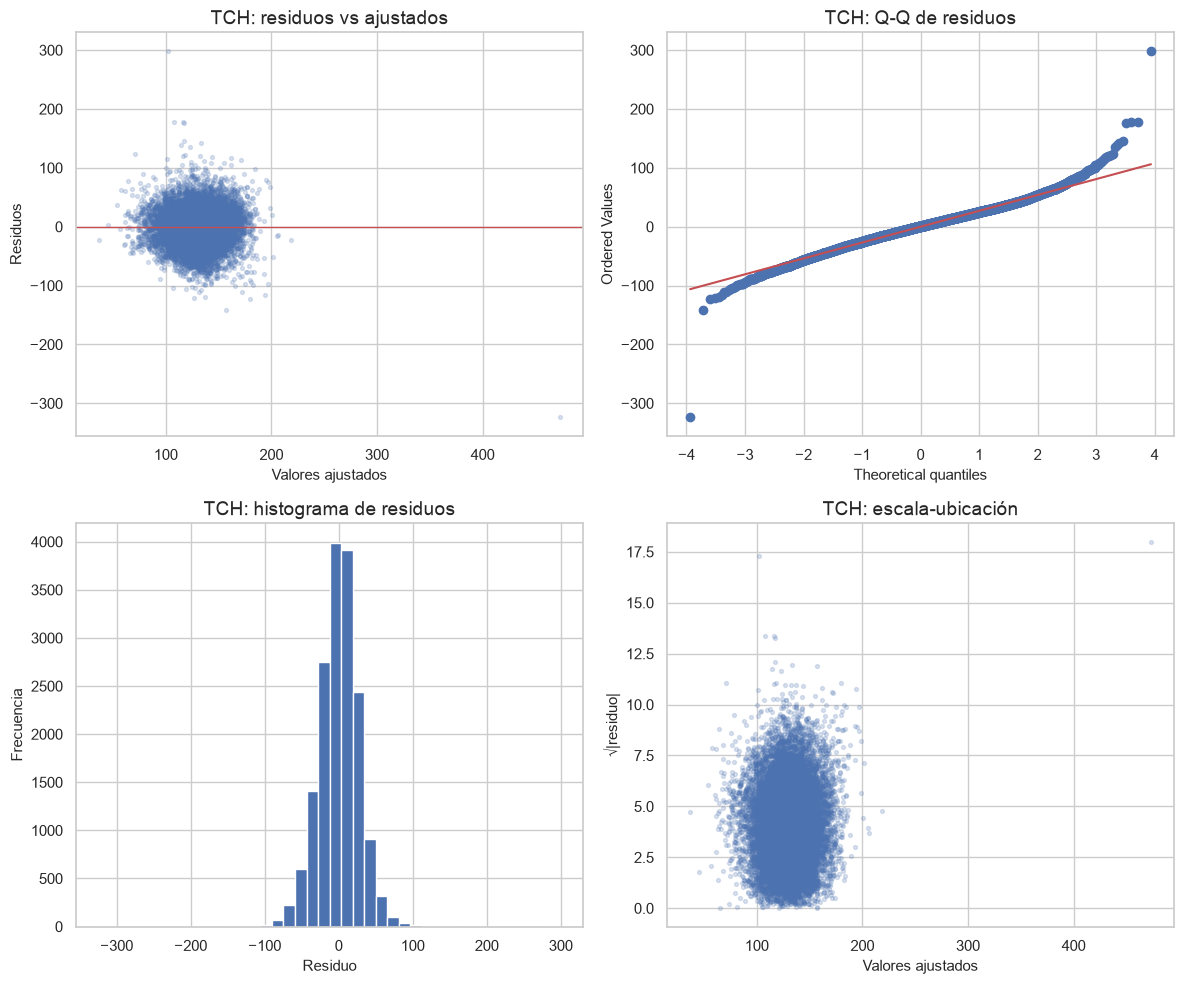

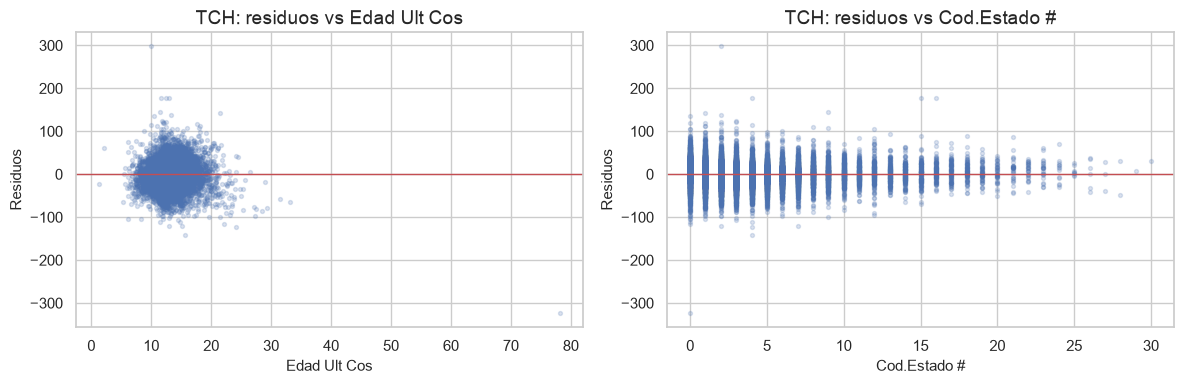

TCH | n = 16,821  |  media residuo = -0.0000  |  asimetría = -0.030
  Breusch-Pagan (homocedasticidad): LM = 1215.7  p = 6.26e-219
  (p < 0.05 → se rechaza varianza constante; con este n el test es muy sensible)

--- %Sac.Caña ---


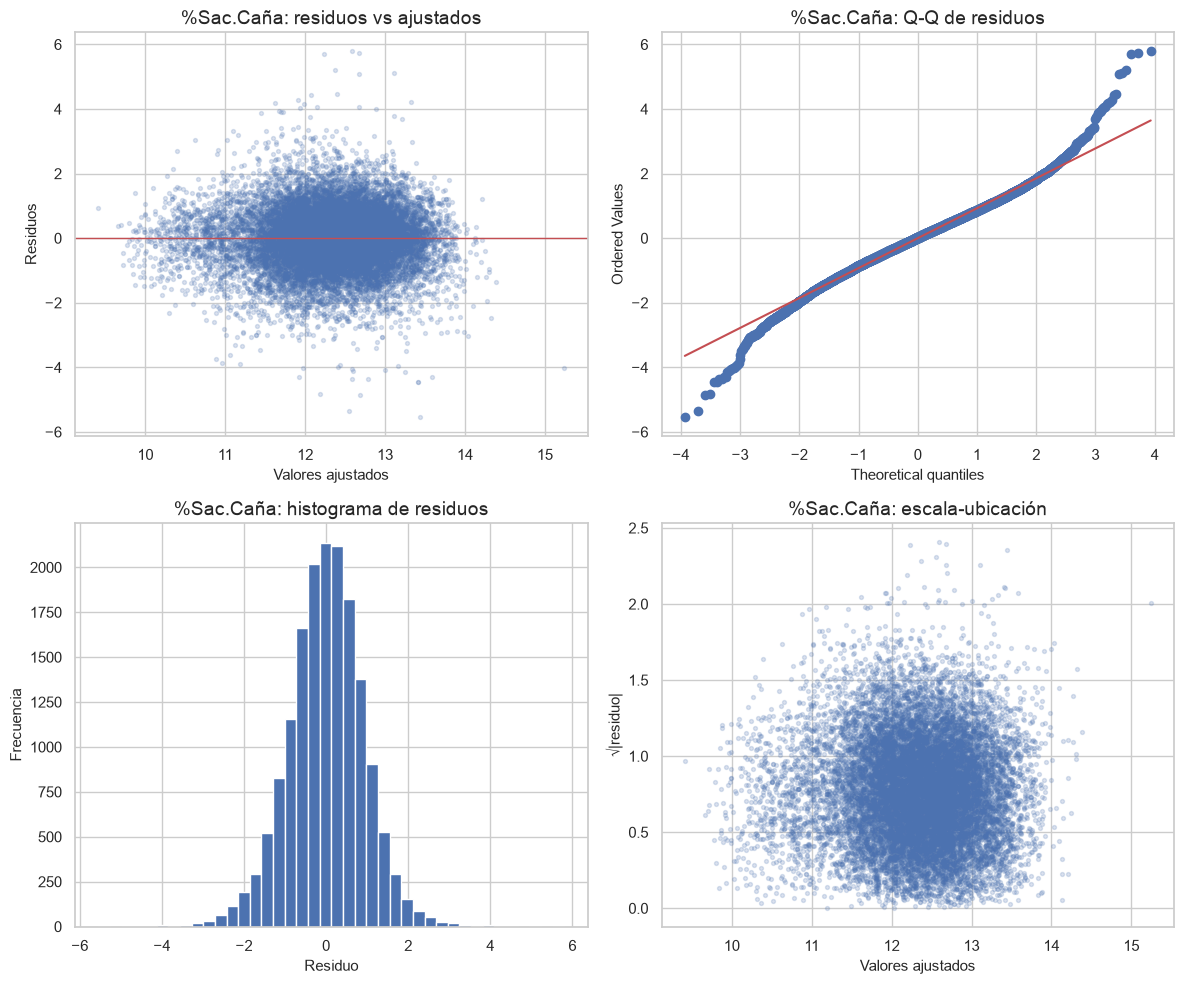

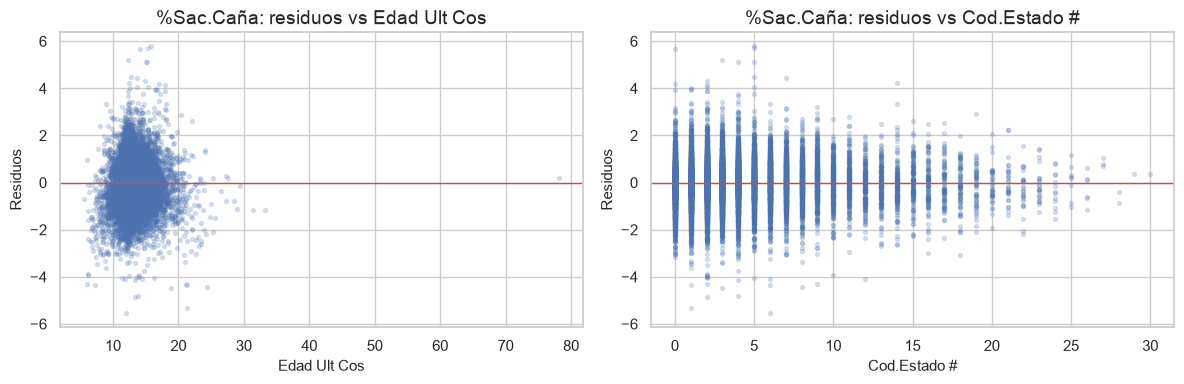

%Sac.Caña | n = 16,479  |  media residuo = -0.0000  |  asimetría = -0.062
  Breusch-Pagan (homocedasticidad): LM = 582.0  p = 3.99e-90
  (p < 0.05 → se rechaza varianza constante; con este n el test es muy sensible)


In [7]:
from statsmodels.stats.diagnostic import het_breuschpagan

# het_breuschpagan: test de homocedasticidad (H0: Var(e) constante).
# Con n ≈ 16.800 el p-valor cae fácil; el gráfico residuos vs ŷ manda más que el p.

def diagnosticos_ols(modelo, X, nombre):
    """Supuestos del lineal: residuos vs ŷ, Q-Q, histograma, scale-location, residuos vs Edad/Cod.Estado, y Breusch-Pagan (H0: varianza constante)."""
    e = pd.Series(modelo.resid, index=getattr(modelo.resid, "index", None))
    yhat = pd.Series(modelo.fittedvalues, index=getattr(modelo.fittedvalues, "index", None))

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes[0, 0].scatter(yhat, e, s=8, alpha=0.2, color="#4C72B0")
    axes[0, 0].axhline(0, color="#C44E52", lw=1)
    axes[0, 0].set_xlabel("Valores ajustados")
    axes[0, 0].set_ylabel("Residuos")
    axes[0, 0].set_title(f"{nombre}: residuos vs ajustados")

    stats.probplot(e, dist="norm", plot=axes[0, 1])
    axes[0, 1].set_title(f"{nombre}: Q-Q de residuos")

    axes[1, 0].hist(e, bins=40, color="#4C72B0", edgecolor="white")
    axes[1, 0].set_xlabel("Residuo")
    axes[1, 0].set_ylabel("Frecuencia")
    axes[1, 0].set_title(f"{nombre}: histograma de residuos")

    axes[1, 1].scatter(yhat, np.sqrt(np.abs(e)), s=8, alpha=0.2, color="#4C72B0")
    axes[1, 1].set_xlabel("Valores ajustados")
    axes[1, 1].set_ylabel("√|residuo|")
    axes[1, 1].set_title(f"{nombre}: escala-ubicación")
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, col in zip(axes, ["Edad Ult Cos", "Cod.Estado #"]):
        ax.scatter(X[col], e, s=8, alpha=0.2, color="#4C72B0")
        ax.axhline(0, color="#C44E52", lw=1)
        ax.set_xlabel(col)
        ax.set_ylabel("Residuos")
        ax.set_title(f"{nombre}: residuos vs {col}")
    plt.tight_layout()
    plt.show()

    lm, lm_p, fstat, f_p = het_breuschpagan(e, modelo.model.exog)
    print(
        f"{nombre} | n = {len(e):,}  |  "
        f"media residuo = {e.mean():.4f}  |  "
        f"asimetría = {e.skew():.3f}"
    )
    print(f"  Breusch-Pagan (homocedasticidad): LM = {lm:.1f}  p = {lm_p:.2e}")
    print("  (p < 0.05 → se rechaza varianza constante; con este n el test es muy sensible)")


print("--- TCH ---")
diagnosticos_ols(modelo_tch, X_train, "TCH")

print("\n--- %Sac.Caña ---")
diagnosticos_ols(modelo_sac, X_train_sac, "%Sac.Caña")

**Qué muestra este paso**

Los gráficos son el criterio; el Breusch-Pagan solo cuantifica lo que ya se ve.

- **Linealidad.** Residuos vs ajustados no deben formar curva. Si vs `Cod.Estado #` queda un patrón (el TCH cae fuerte al inicio de la soca y luego se aplana), el lineal **promedia** esa no linealidad: el coef −0.6 t/ha por corte es una recta sobre un codo. `Edad Ult Cos` suele verse más plana (el efecto es más lineal).
- **Homocedasticidad.** Abanico en residuos vs ajustados y en escala-ubicación = varianza que crece con el TCH predicho (lotes chicos / extremos del paso 7). Breusch-Pagan casi seguro rechaza con n grande. Por eso se reportan **MAE y RMSE**: el RMSE castiga más esos puntos.
- **Normalidad.** El histograma de residuos es casi simétrico (como los targets). El Q-Q se sale en las colas. No impide interpretar signos; sí desaconseja intervalos que asuman gaussianidad estricta. No se reporta Shapiro.
- **Independencia.** Una suerte entra varias veces (distintos `Período`). Los errores de un lote se parecen en el tiempo. Los p-valores del paso 18 están **optimistas**. Se anota; no se pone un modelo mixto aquí.

**Decisión.** El lineal cumple como **benchmark interpretable**, no como el proceso que generó el TCH. Limitaciones ya listas para el informe: soca no lineal, heterocedasticidad, lotes repetidos, lluvias de ciclo no significativas. Siguiente: métricas en el **test** (R², RMSE, MAE), una sola vez.


## 20. Métricas en el test (hold-out)

Se reportan **R², RMSE y MAE** en el 20 % reservado. Ese bloque se toca **ahora**, una vez por modelo: no se vuelve a elegir variables ni a imputar. Train se muestra solo para ver sobreajuste.

Unidades: TCH en t/ha; `%Sac.Caña` en puntos porcentuales. No se comparan los dos R² entre sí como si fueran la misma escala. RMSE penaliza más los extremos (heterocedasticidad del paso 19); MAE es la lectura más estable.


Hold-out 80/20 — el test no se usó para ajustar


,modelo,conjunto,n,R²,RMSE,MAE
0,OLS TCH,train,16821,0.310,27.168,20.793
1,OLS TCH,test,4206,0.322,27.440,21.176
2,OLS %Sac.Caña,train,16479,0.344,0.932,0.715
3,OLS %Sac.Caña,test,4099,0.347,0.909,0.706


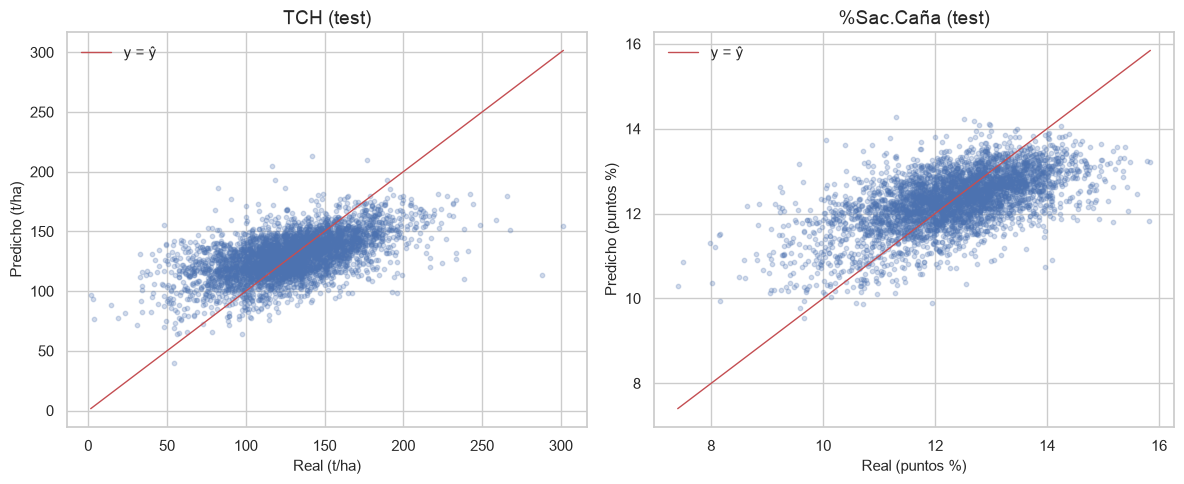

Sesgo medio en test (real − predicho): TCH -1.32 t/ha  |  %Sac -0.005 puntos


In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# R², RMSE y MAE en train (ajuste) y test (generalización).
# El test no se usó para elegir predictores ni para imputar.

def metricas(y_true, y_pred):
    """R², RMSE y MAE. RMSE penaliza más los errores grandes (heterocedasticidad); MAE es t/ha o puntos de sacarosa en promedio."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        "n": int(len(y_true)),
        "R²": r2_score(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
    }


def predecir_ols(modelo, X):
    """Predicción del OLS alineando columnas con las del ajuste (añade constante y reindexa). Sirve para train y test."""
    Xc = sm.add_constant(X, has_constant="add")
    Xc = Xc.reindex(columns=modelo.model.exog_names, fill_value=0.0)
    return modelo.predict(Xc)


pred_tr_tch = predecir_ols(modelo_tch, X_train)
pred_te_tch = predecir_ols(modelo_tch, X_test)
pred_tr_sac = predecir_ols(modelo_sac, X_train_sac)
pred_te_sac = predecir_ols(modelo_sac, X_test_sac)

tabla_metricas = pd.DataFrame([
    {"modelo": "OLS TCH", "conjunto": "train", **metricas(y_train_tch, pred_tr_tch)},
    {"modelo": "OLS TCH", "conjunto": "test", **metricas(y_test_tch, pred_te_tch)},
    {"modelo": "OLS %Sac.Caña", "conjunto": "train", **metricas(y_train_sac, pred_tr_sac)},
    {"modelo": "OLS %Sac.Caña", "conjunto": "test", **metricas(y_test_sac, pred_te_sac)},
])
print("Hold-out 80/20 — el test no se usó para ajustar")
display(tabla_metricas.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, y, yhat, titulo, unidad in [
    (axes[0], y_test_tch, pred_te_tch, "TCH (test)", "t/ha"),
    (axes[1], y_test_sac, pred_te_sac, "%Sac.Caña (test)", "puntos %"),
]:
    ax.scatter(y, yhat, s=10, alpha=0.25, color="#4C72B0")
    lo = min(np.min(y), np.min(yhat))
    hi = max(np.max(y), np.max(yhat))
    ax.plot([lo, hi], [lo, hi], color="#C44E52", lw=1, label="y = ŷ")
    ax.set_xlabel(f"Real ({unidad})")
    ax.set_ylabel(f"Predicho ({unidad})")
    ax.set_title(titulo)
    ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print(
    "Sesgo medio en test (real − predicho): "
    f"TCH {np.mean(np.asarray(y_test_tch) - pred_te_tch):.2f} t/ha  |  "
    f"%Sac {np.mean(np.asarray(y_test_sac) - pred_te_sac):.3f} puntos"
)

**Qué muestra este paso**

- **Test vs train.** Si R² / RMSE / MAE del test están cerca del train, el lineal no se memorizó el 80%. Una caída fuerte sería sobreajuste; con un OLS sin hiperparámetros no es lo esperable.
- **TCH.** El R² de train era ~0.31: el test debería vivir en esa banda. MAE en t/ha es lo que un ingenio entiende (“nos desviamos X toneladas por hectárea”). RMSE > MAE confirma colas (lotes chicos / semilla del paso 7).
- **`%Sac.Caña`.** R² train ~0.34. La dosis y las lluvias de maduración mueven la calidad; el error se lee en puntos de sacarosa, no en t/ha.
- **Nube real vs predicho.** Debe seguir la diagonal. Abanico al subir el TCH = la heterocedasticidad del paso 19, no un bug del split.
- El test **no se reutiliza** para tirar variables ni para elegir Ridge. Eso es el paso 21 (k-fold en train).

**Decisión.** Quedan las métricas de hold-out del benchmark. Siguiente: **k-fold (k = 5) sobre el train** para un RMSE/R² más estable; Ridge/Lasso como comparación de regularización.

## 21. Validación cruzada en el train (k = 5)

K-fold **sobre el entrenamiento** (k = 5) para estimar el desempeño y, si hay hiperparámetros, elegirlos. El OLS no tiene hiperparámetro: el CV da un RMSE/R² más estable que un solo train. **Ridge** (y Lasso) sí eligen `alpha` por CV en train; el test se evalúa **después**, una vez.

La imputación y las dummies ya se fijaron con todo el train (paso 16): el k-fold de este paso estima el error del lineal sobre esa matriz, no reimputa en cada fold (anidarlo sería el siguiente nivel de rigor). Ridge/Lasso van con `StandardScaler` en un pipeline: la penalización depende de la escala.


In [9]:
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.model_selection import GridSearchCV, KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Modelos sklearn de esta celda (el OLS interpretable sigue siendo statsmodels, paso 18):
# - LinearRegression: MCO sin penalizar. Sirve para k-fold comparable a Ridge/Lasso.
# - Ridge: penaliza Σ β² (encoge, no apaga). Pipeline StandardScaler → Ridge(max_iter=10_000).
# - Lasso: penaliza Σ |β| (puede dejar β=0). Mismo scaler; max_iter=20_000 (converge más lento).
# Hiperparámetro alpha: grilla logspace(-2, 4, 20) → 0.01 … 10.000. Se elige el de menor RMSE de CV.
# Validación: KFold(k=5, shuffle=True, random_state=42) SOLO en train. GridSearchCV scoring =
# neg_root_mean_squared_error; n_jobs=1; refit=True (reajusta con alpha* en todo el train).

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "R2": "r2",
    "RMSE": "neg_root_mean_squared_error",
    "MAE": "neg_mean_absolute_error",
}


def resumen_cv(est, X, y, nombre):
    """K-fold sobre un estimador sklearn: media y desvío de R², RMSE y MAE. sklearn reporta RMSE/MAE en negativo; aquí se vuelven a positivo."""
    cvres = cross_validate(est, X, y, cv=cv, scoring=scoring)
    fila = {
        "modelo": nombre,
        "R²_CV": cvres["test_R2"].mean(),
        "R²_CV_sd": cvres["test_R2"].std(),
        "RMSE_CV": -cvres["test_RMSE"].mean(),
        "RMSE_CV_sd": cvres["test_RMSE"].std(),
        "MAE_CV": -cvres["test_MAE"].mean(),
        "MAE_CV_sd": cvres["test_MAE"].std(),
    }
    print(
        f"{nombre}: R² {fila['R²_CV']:.3f} ± {fila['R²_CV_sd']:.3f}  |  "
        f"RMSE {fila['RMSE_CV']:.3f} ± {fila['RMSE_CV_sd']:.3f}  |  "
        f"MAE {fila['MAE_CV']:.3f} ± {fila['MAE_CV_sd']:.3f}"
    )
    return fila


def ajustar_penalizado(estimador, grilla, X_tr, y_tr, X_te, y_te, nombre):
    """Pipeline StandardScaler → Ridge o Lasso. GridSearchCV elige alpha minimizando RMSE de CV (refit=True). El test se evalúa una sola vez, con alpha ya fijado."""
    pipe = Pipeline([
        ("escala", StandardScaler()),
        ("modelo", estimador),
    ])
    gs = GridSearchCV(
        pipe,
        param_grid=grilla,
        cv=cv,
        scoring="neg_root_mean_squared_error",
        n_jobs=1,
        refit=True,
    )
    gs.fit(X_tr, y_tr)
    alpha = gs.best_params_["modelo__alpha"]
    pred_te = gs.predict(X_te)
    met_te = metricas(y_te, pred_te)
    print(
        f"{nombre}: alpha* = {alpha:.4g}  |  "
        f"RMSE CV = {-gs.best_score_:.3f}  |  "
        f"test R² = {met_te['R²']:.3f}  RMSE = {met_te['RMSE']:.3f}  MAE = {met_te['MAE']:.3f}"
    )
    return gs, {
        "modelo": nombre,
        "alpha": alpha,
        "RMSE_CV": -gs.best_score_,
        **{f"{k}_test": v for k, v in met_te.items() if k != "n"},
    }


print("OLS — k-fold k=5 en train (sin tocar el test)")
filas_cv = [
    resumen_cv(LinearRegression(), X_train, y_train_tch, "OLS TCH"),
    resumen_cv(LinearRegression(), X_train_sac, y_train_sac, "OLS %Sac.Caña"),
]
display(pd.DataFrame(filas_cv).round(3))

alphas = np.logspace(-2, 4, 20)
print("\nRidge / Lasso — alpha por CV en train; métricas de test al final")
gs_ridge_tch, r1 = ajustar_penalizado(
    Ridge(max_iter=10000), {"modelo__alpha": alphas},
    X_train, y_train_tch, X_test, y_test_tch, "Ridge TCH",
)
gs_ridge_sac, r2 = ajustar_penalizado(
    Ridge(max_iter=10000), {"modelo__alpha": alphas},
    X_train_sac, y_train_sac, X_test_sac, y_test_sac, "Ridge %Sac.Caña",
)
gs_lasso_tch, r3 = ajustar_penalizado(
    Lasso(max_iter=20000), {"modelo__alpha": alphas},
    X_train, y_train_tch, X_test, y_test_tch, "Lasso TCH",
)
gs_lasso_sac, r4 = ajustar_penalizado(
    Lasso(max_iter=20000), {"modelo__alpha": alphas},
    X_train_sac, y_train_sac, X_test_sac, y_test_sac, "Lasso %Sac.Caña",
)

ols_test = tabla_metricas.loc[tabla_metricas["conjunto"] == "test"].copy()
comparacion = pd.DataFrame([
    {"modelo": "OLS TCH", "RMSE_CV": filas_cv[0]["RMSE_CV"], "R²_test": ols_test.loc[ols_test["modelo"]=="OLS TCH", "R²"].iloc[0], "RMSE_test": ols_test.loc[ols_test["modelo"]=="OLS TCH", "RMSE"].iloc[0], "MAE_test": ols_test.loc[ols_test["modelo"]=="OLS TCH", "MAE"].iloc[0]},
    {"modelo": "Ridge TCH", **{k: r1[k] for k in ["RMSE_CV"]}, "R²_test": r1["R²_test"], "RMSE_test": r1["RMSE_test"], "MAE_test": r1["MAE_test"]},
    {"modelo": "Lasso TCH", "RMSE_CV": r3["RMSE_CV"], "R²_test": r3["R²_test"], "RMSE_test": r3["RMSE_test"], "MAE_test": r3["MAE_test"]},
    {"modelo": "OLS %Sac.Caña", "RMSE_CV": filas_cv[1]["RMSE_CV"], "R²_test": ols_test.loc[ols_test["modelo"]=="OLS %Sac.Caña", "R²"].iloc[0], "RMSE_test": ols_test.loc[ols_test["modelo"]=="OLS %Sac.Caña", "RMSE"].iloc[0], "MAE_test": ols_test.loc[ols_test["modelo"]=="OLS %Sac.Caña", "MAE"].iloc[0]},
    {"modelo": "Ridge %Sac.Caña", "RMSE_CV": r2["RMSE_CV"], "R²_test": r2["R²_test"], "RMSE_test": r2["RMSE_test"], "MAE_test": r2["MAE_test"]},
    {"modelo": "Lasso %Sac.Caña", "RMSE_CV": r4["RMSE_CV"], "R²_test": r4["R²_test"], "RMSE_test": r4["RMSE_test"], "MAE_test": r4["MAE_test"]},
])
print("\nComparación (CV en train; test una sola vez)")
display(comparacion.round(3))

# Lasso: cuántas variables quedan (selección por penalización L1)
def n_coef_lasso(gs):
    """Cuántos coeficientes Lasso dejó distintos de cero (|β|>1e-8). Resumen de la selección por penalización L1."""
    coef = gs.best_estimator_.named_steps["modelo"].coef_
    return int(np.sum(np.abs(coef) > 1e-8)), int(len(coef))

n1, p1 = n_coef_lasso(gs_lasso_tch)
n2, p2 = n_coef_lasso(gs_lasso_sac)
print(f"Lasso TCH: {n1} / {p1} coeficientes ≠ 0")
print(f"Lasso %Sac.Caña: {n2} / {p2} coeficientes ≠ 0")


OLS — k-fold k=5 en train (sin tocar el test)
OLS TCH: R² 0.304 ± 0.016  |  RMSE 27.293 ± 0.263  |  MAE 20.876 ± 0.222
OLS %Sac.Caña: R² 0.338 ± 0.010  |  RMSE 0.936 ± 0.009  |  MAE 0.719 ± 0.006


,modelo,R²_CV,R²_CV_sd,RMSE_CV,RMSE_CV_sd,MAE_CV,MAE_CV_sd
0,OLS TCH,0.304,0.016,27.293,0.263,20.876,0.222
1,OLS %Sac.Caña,0.338,0.010,0.936,0.009,0.719,0.006



Ridge / Lasso — alpha por CV en train; métricas de test al final
Ridge TCH: alpha* = 61.58  |  RMSE CV = 27.292  |  test R² = 0.322  RMSE = 27.441  MAE = 21.175
Ridge %Sac.Caña: alpha* = 127.4  |  RMSE CV = 0.935  |  test R² = 0.347  RMSE = 0.909  MAE = 0.706
Lasso TCH: alpha* = 0.02069  |  RMSE CV = 27.291  |  test R² = 0.322  RMSE = 27.438  MAE = 21.172
Lasso %Sac.Caña: alpha* = 0.01  |  RMSE CV = 0.937  |  test R² = 0.342  RMSE = 0.913  MAE = 0.709

Comparación (CV en train; test una sola vez)


,modelo,RMSE_CV,R²_test,RMSE_test,MAE_test
0,OLS TCH,27.293,0.322,27.440,21.176
1,Ridge TCH,27.292,0.322,27.441,21.175
2,Lasso TCH,27.291,0.322,27.438,21.172
3,OLS %Sac.Caña,0.936,0.347,0.909,0.706
4,Ridge %Sac.Caña,0.935,0.347,0.909,0.706
5,Lasso %Sac.Caña,0.937,0.342,0.913,0.709


Lasso TCH: 54 / 54 coeficientes ≠ 0
Lasso %Sac.Caña: 43 / 53 coeficientes ≠ 0


**Qué muestra este paso**

- **OLS k-fold.** Cinco particiones del train, mismo `random_state=42`. El RMSE_CV debe parecerse al RMSE de train del paso 20; la desviación entre folds dice si un 20% interno cambia mucho el error. Es la estimación de error más estable **sin gastar el test**.
- **Ridge.** `alpha` se elige minimizando RMSE de CV. Con p ≈ 50 y n ≈ 16.000, Ridge suele empatar al OLS: hay dato de sobra y poca sobreparametrización. Si el test no mejora, el benchmark lineal **se queda** como modelo a interpretar (signos y p-valores).
- **Lasso.** Misma lógica, más selección: cuenta cuántos coeficientes se van a cero. Sirve como comparación de regularización, aunque el OLS siga siendo el que se lee agronómicamente.
- El test de Ridge/Lasso se calculó **después** de fijar `alpha`. No se eligió el modelo mirando el 20%.

**Decisión.** Tabla OLS vs Ridge vs Lasso (RMSE_CV y test). La interpretación de negocio sigue siendo el OLS del paso 18. Siguiente: Random Forest como comparación de desempeño, y cierre (qué mandó, supuestos, limitaciones).


## 22. Benchmark no lineal: Random Forest

El paso 19 mostró que `Cod.Estado #` no mueve el TCH en línea recta (un codo: la soca cae al inicio y luego se aplana) y que los residuos son heterocedásticos. Un bosque puede recortar esos tramos; el OLS no. Socadagui-Casas et al. (2026) reportan que CatBoost y Random Forest superan a los lineales al predecir rendimiento de caña en el Valle del Cauca.

Aquí el bosque es **solo comparación de desempeño** (RMSE / MAE / R²). No sustituye al OLS: no entrega p-valores ni signos de coeficientes. Las palancas de negocio del Ingenio siguen leyéndose en el lineal del paso 18.


In [10]:
from sklearn.ensemble import RandomForestRegressor

# RandomForestRegressor: promedio de árboles de regresión. Comparación de desempeño, no de signos.
# Hiperparámetros fijos (no hay grid; el lineal ya gastó la CV en alpha):
#   n_estimators=300   — número de árboles; baja la varianza del ensemble
#   max_depth=None     — sin tope de profundidad; el recorte lo hace la hoja mínima
#   min_samples_leaf=5 — no parte hojas con <5 lotes (suaviza, evita memorizar)
#   random_state=42    — el mismo del hold-out
#   n_jobs=-1          — usa todos los núcleos
# CV: el mismo KFold(k=5) de Ridge/Lasso. feature_importances_ = reducción media de Gini (no es p-valor).

def ajustar_rf(X_tr, y_tr, X_te, y_te, nombre, cv):
    """Ajusta RandomForestRegressor, reporta CV (mismo KFold que Ridge/Lasso) y métricas de test. Devuelve el bosque y un dict con test + RMSE_CV / R²_CV (para la tabla comparacion)."""
    rf = RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    cvres = cross_validate(
        rf, X_tr, y_tr, cv=cv,
        scoring={"R2": "r2", "RMSE": "neg_root_mean_squared_error", "MAE": "neg_mean_absolute_error"},
    )
    rf.fit(X_tr, y_tr)
    pred_te = rf.predict(X_te)
    met_te = metricas(y_te, pred_te)
    met_te["RMSE_CV"] = float(-cvres["test_RMSE"].mean())
    met_te["R²_CV"] = float(cvres["test_R2"].mean())
    met_te["R²_CV_sd"] = float(cvres["test_R2"].std())
    print(
        f"{nombre}: R²_CV {met_te['R²_CV']:.3f} ± {met_te['R²_CV_sd']:.3f}  |  "
        f"RMSE_CV {met_te['RMSE_CV']:.3f}  |  "
        f"test R²={met_te['R²']:.3f}  RMSE={met_te['RMSE']:.3f}  MAE={met_te['MAE']:.3f}"
    )
    return rf, met_te

rf_tch, met_rf_tch = ajustar_rf(X_train, y_train_tch, X_test, y_test_tch, "RF TCH", cv)
rf_sac, met_rf_sac = ajustar_rf(X_train_sac, y_train_sac, X_test_sac, y_test_sac, "RF %Sac.Caña", cv)

comparacion_rf = pd.DataFrame([
    {"modelo": "RF TCH", "RMSE_CV": met_rf_tch["RMSE_CV"], "R²_test": met_rf_tch["R²"], "RMSE_test": met_rf_tch["RMSE"], "MAE_test": met_rf_tch["MAE"]},
    {"modelo": "RF %Sac.Caña", "RMSE_CV": met_rf_sac["RMSE_CV"], "R²_test": met_rf_sac["R²"], "RMSE_test": met_rf_sac["RMSE"], "MAE_test": met_rf_sac["MAE"]},
])
display(pd.concat([comparacion, comparacion_rf], ignore_index=True).round(3))

importancias_tch = pd.Series(rf_tch.feature_importances_, index=X_train.columns).sort_values(ascending=False)
importancias_sac = pd.Series(rf_sac.feature_importances_, index=X_train_sac.columns).sort_values(ascending=False)
print("\nTop 10 importancias RF — TCH:")
display(importancias_tch.head(10))
print("\nTop 10 importancias RF — %Sac.Caña:")
display(importancias_sac.head(10))

RF TCH: R²_CV 0.454 ± 0.021  |  RMSE_CV 24.163  |  test R²=0.468  RMSE=24.307  MAE=17.992
RF %Sac.Caña: R²_CV 0.478 ± 0.008  |  RMSE_CV 0.831  |  test R²=0.501  RMSE=0.794  MAE=0.611


,modelo,RMSE_CV,R²_test,RMSE_test,MAE_test
0,OLS TCH,27.293,0.322,27.440,21.176
1,Ridge TCH,27.292,0.322,27.441,21.175
2,Lasso TCH,27.291,0.322,27.438,21.172
3,OLS %Sac.Caña,0.936,0.347,0.909,0.706
4,Ridge %Sac.Caña,0.935,0.347,0.909,0.706
5,Lasso %Sac.Caña,0.937,0.342,0.913,0.709
6,RF TCH,24.163,0.468,24.307,17.992
7,RF %Sac.Caña,0.831,0.501,0.794,0.611



Top 10 importancias RF — TCH:


Edad Ult Cos              0.227246
Dist Km                   0.150855
Cod.Estado #              0.119611
Año                       0.071470
Lluvias Ciclo             0.054165
Semanas mad.              0.048741
Suelo_agrup_CERRITO       0.036041
Lluvias (2 Meses Ant.)    0.033156
M3 Riego                  0.026933
Dosis Madurante           0.021087
dtype: float64


Top 10 importancias RF — %Sac.Caña:


Semanas mad.              0.217740
Edad Ult Cos              0.128103
Dist Km                   0.075673
Lluvias (2 Meses Ant.)    0.072639
Año                       0.067570
Cultivo_Organico          0.063775
Cod.Estado #              0.044468
Lluvias Ciclo             0.038903
Mes_06                    0.030137
Mes_09                    0.022813
dtype: float64

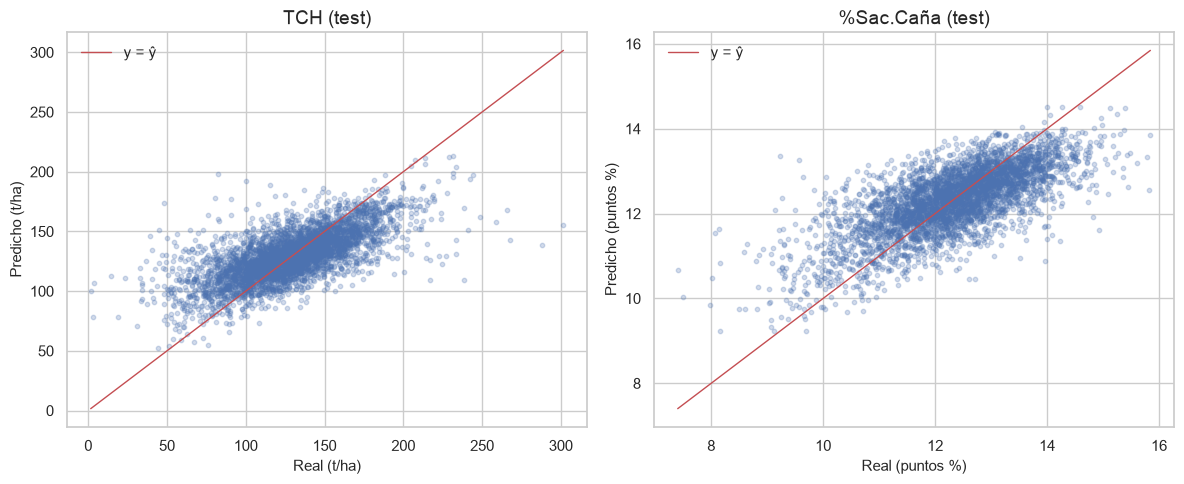

In [11]:
# Mismo gráfico que el OLS del paso 20 (scatter real vs. predicho + línea y = ŷ), ahora con RF en test.
pred_rf_te_tch = rf_tch.predict(X_test)
pred_rf_te_sac = rf_sac.predict(X_test_sac)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, y, yhat, titulo, unidad in [
    (axes[0], y_test_tch, pred_rf_te_tch, "TCH (test)", "t/ha"),
    (axes[1], y_test_sac, pred_rf_te_sac, "%Sac.Caña (test)", "puntos %"),
]:
    ax.scatter(y, yhat, s=10, alpha=0.25, color="#4C72B0")
    lo = min(np.min(y), np.min(yhat))
    hi = max(np.max(y), np.max(yhat))
    ax.plot([lo, hi], [lo, hi], color="#C44E52", lw=1, label="y = ŷ")
    ax.set_xlabel(f"Real ({unidad})")
    ax.set_ylabel(f"Predicho ({unidad})")
    ax.set_title(titulo)
    ax.legend(frameon=False)
plt.tight_layout()
plt.show()


**Qué muestra este paso**

Random Forest **sí bajó el error** respecto al OLS del paso 20/21, en las dos respuestas.

- **TCH (test).** OLS: R² = 0.322, RMSE = 27.440 t/ha, MAE = 21.176 t/ha. RF: R² = 0.468, RMSE = 24.307 t/ha, MAE = 17.992 t/ha. El RMSE cae **3.13 t/ha** y el MAE **3.18 t/ha**. En CV del train el salto es del mismo orden (R² 0.304 → 0.454; RMSE 27.29 → 24.16).
- **%Sac.Caña (test).** OLS: R² = 0.347, RMSE = 0.909, MAE = 0.706. RF: R² = 0.501, RMSE = 0.794, MAE = 0.611. El RMSE cae **0.115 puntos porcentuales** de sacarosa y el MAE **0.095**. CV: R² 0.338 → 0.478; RMSE 0.936 → 0.831.
- Ridge y Lasso del paso 21 empataron al OLS (a tres milésimas). El bosque no: recorta el codo de `Cod.Estado #` y la heterocedasticidad que el lineal no puede.

**Importancias vs OLS del paso 18 (variables que el lineal marcó como significativas: `Edad Ult Cos`, `Cod.Estado #`, `Destino 1=Semilla`, `Dosis Madurante`, `Año`).**

- **Coincide (refuerza el lineal).** En TCH el top del bosque es `Edad Ult Cos` (0.227), `Cod.Estado #` (0.120) y `Año` (0.071). `Dosis Madurante` entra al top 10, más abajo (0.021). `Dist Km` queda 2.ª (0.151): en el OLS también era significativa (≈ −0.24 t/ha por km). En sacarosa coinciden `Semanas mad.`, lluvias de 2 meses, `Cod.Estado #` y cultivo orgánico.
- **No coincide (no ocultarlo).** `Destino 1=Semilla` **no entra al top 10** de ningún bosque, pese a −20.4 t/ha y p < 0.001 en el OLS. Es un 0/1 raro (~1 % de lotes): el Gini reparte poco entre pocos cortes, y el lineal sí aísla ese salto. En sacarosa el OLS daba el mayor t a `Dosis Madurante` (+0.55 puntos); el RF pone primero `Semanas mad.` (0.218) y **no mete la dosis en el top 10**. El bloque de maduración ya era colineal (corr dosis–`madurada` ≈ 0.92; VIF de alerta): el bosque parte por semanas y deja la dosis atrás. `Edad Ult Cos` y `Año` suben en RF-sacarosa aunque el OLS las tenía no significativas (p = 0.59 y 0.37): ahí el lineal y el no lineal no cuentan la misma historia.

**Advertencia metodológica.** `feature_importances_` de `RandomForestRegressor` es importancia Gini / MDI (reducción media de impureza al partir), **no un p-valor** y no se compara 1 a 1 con el OLS. Tiene sesgo conocido a favorecer numéricas continuas (muchos puntos de corte posibles) y a subestimar binarias raras: exactamente el caso de `Destino 1=Semilla`. Lo más riguroso sería contrastar con *permutation importance* (`sklearn.inspection.permutation_importance`) para ver si esas variables realmente pesan menos en el bosque o si es artefacto del MDI. Aquí no se calcula; queda como nota metodológica.

**Decisión.** Random Forest gana en RMSE y MAE. El modelo que se interpreta para las decisiones de negocio del Ingenio Providencia **sigue siendo el OLS del paso 18** (signos, magnitudes, p-valores). El bosque no los entrega.


## 23. Conclusiones

Queda un **benchmark lineal interpretable** para `TCH` y `%Sac.Caña`, con hold-out 80/20, supuestos, R² / RMSE / MAE y k-fold en train. La clasificación es `modelo_ipsa.ipynb`.

### Qué modelo se queda

**OLS múltiple**, el mismo para leer signos y p-valores. Ridge (α ≈ 62 en TCH, ≈ 127 en sacarosa) y Lasso empatan el test al segundo decimal: TCH R² = 0.322, RMSE ≈ 27.4 t/ha, MAE ≈ 21.2; sacarosa R² = 0.347, RMSE ≈ 0.91, MAE ≈ 0.71. Con n ≈ 16.800 no hay sobreparametrización que penalizar. Lasso en TCH no apaga ningún coeficiente (54/54); en sacarosa deja 43/53. Sirven como fila de regularización, no como modelo de negocio.

Random Forest **superó** a OLS/Ridge/Lasso en desempeño puro: RMSE de test 24.307 t/ha vs 27.440 (TCH) y 0.794 vs 0.909 puntos (sacarosa); MAE 17.992 vs 21.176 y 0.611 vs 0.706. No sustituye al OLS para el negocio: el bosque no da signos ni p-valores. Van los dos, con propósitos distintos — **OLS interpreta, RF predice mejor**.

### Desempeño

| Modelo | R² CV train | R² test | RMSE test | MAE test |
|---|---|---|---|---|
| OLS TCH | 0.304 ± 0.016 | **0.322** | **27.4 t/ha** | **21.2 t/ha** |
| OLS %Sac.Caña | 0.338 ± 0.010 | **0.347** | **0.91 puntos** | **0.71 puntos** |
| RF TCH | 0.454 ± 0.021 | **0.468** | **24.307 t/ha** | **17.992 t/ha** |
| RF %Sac.Caña | 0.478 ± 0.008 | **0.501** | **0.794 puntos** | **0.611 puntos** |

Train y test están al mismo nivel (sacarosa incluso un poco mejor en test): no hay sobreajuste. El k-fold confirma el hold-out. Sesgo de test: −1.3 t/ha y −0.005 puntos de sacarosa (casi centrado). MAE/TCH ≈ 21 sobre una media de ~130 t/ha: el lineal acierta el orden de magnitud, no el lote. RMSE > MAE encaja con la heterocedasticidad del paso 19.

### Qué variables mandan (OLS)

**TCH (productividad)**

- `Edad Ult Cos`: **+5 t/ha por mes** de ciclo. Es el predictor numérico más claro.
- `Destino 1=Semilla`: **−21 t/ha**. Semillero, no molino.
- `Cod.Estado #`: **−0.6 t/ha por corte**. La soca pierde desde la plantilla (paso 11); el lineal pone una recta sobre un codo.
- `Año` (desde 2017): **−3.5 t/ha/año**. Tendencia a la baja en el histórico.
- Distancia al ingenio negativa y pequeña; `M3 Riego` positivo; **`Lluvias Ciclo` y `Num.Riegos` no significativas**.
- Zona IP02/IP03/IP05 por encima de la referencia; CC05-430 sube TCH; CC85-92 y CC93-4418 lo bajan.

**`%Sac.Caña` (calidad)**

- `Dosis Madurante`: **+0.55 puntos** por unidad. Palanca de maduración sobre la calidad.
- Lluvias de **2 meses antes**: signo **negativo** (dilución en maduración).
- Cultivo **orgánico: −1.0 punto**. Paso 11 y práctica de Providencia.
- Edad de *este* ciclo no mueve la sacarosa; el número de corte, apenas. Destino semilla no es significativo en calidad.
- CC93-4418 a favor de azúcar y en contra de TCH: no hay una variedad que gane los dos objetivos.

### Supuestos

Linealidad aproximada, rota en la soca. Homocedasticidad no: abanico con el TCH predicho (lotes chicos). Residuos casi simétricos; Q-Q se sale en colas. Filas no independientes (la misma suerte en varios periodos): p-valores del paso 18 **optimistas**. El lineal es interpretable, no el proceso generador.

### Limitaciones

1. **Sin fertilización** (80–100% nulos). El factor agronómico existe; el histórico no lo mide.
2. **Lluvias de ciclo** no entran en el lineal; zona y mes se las comen, o el efecto no es aditivo (lluvia × suelo × variedad).
3. **R² ≈ 0.32–0.35**: queda ~65% del TCH sin explicar. Un árbol baja el RMSE; no se interpreta igual.
4. Extremos de TCH en 0.1–2 ha: error de denominador, no productividad. No se borraron; MAE es la métrica de trabajo.
5. `Período` partido en Año + Mes; `Tipo Quema = SEMILLA` era destino (colinealidad exacta).

### Qué hacer con esto en Providencia

Priorizar **edad de ciclo y no mandar semillero al modelo de molino**. Madurante y sequía de maduración para sacarosa. Orgánico: esperar ~1 punto menos de azúcar. No usar este OLS para pronosticar un lote al decimal: sí para ordenar palancas (edad, destino, zona, variedad, dosis).
